# Recap:

*   Numpy vector and matrix operations

# Today:

*  More Numpy operations
*  Numpy Linear Algebra








In [ ]:
import numpy as np

## 1. Matrix-vector operation from last time:

Linear equations can also be thought of as “mapping” some input into an output.
$$\underbrace{ u'}_{output} = \underbrace{A}_{operator} \quad \underbrace{u}_{input}$$

One familiar map is a rotation matrix, which takes
coordinates $(x, y)$, rotates them about the origin
clockwise by an angle $\theta$, and returns new coordinates
$(x’, y’)$:
$$ \begin{bmatrix}
  x'\\
  y'
  \end{bmatrix} = \begin{bmatrix}
  \cos\theta & \sin\theta\\
  -\sin \theta &\cos\theta
  \end{bmatrix}
  \begin{bmatrix}
  x\\
  y
  \end{bmatrix}$$

  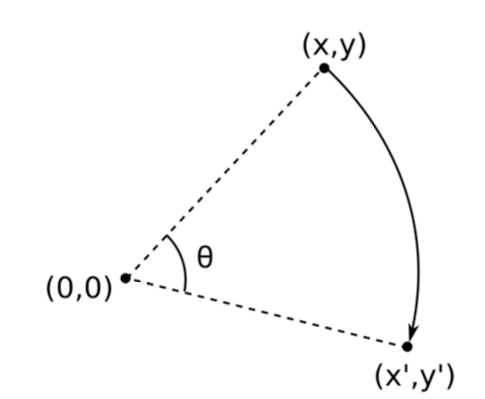

In [ ]:
theta = np.pi/2
#rotation matrix
A = np.array([[np.cos(theta), np.sin(theta)],[-np.sin(theta), np.cos(theta)]])
# input
x = np.array([1,0])
# output
xp = A.dot(x)
xp

array([ 6.123234e-17, -1.000000e+00])

### Application example: image warping
* This matrix equation defines a warping operator:
$$\begin{bmatrix}
i'\\
j'
\end{bmatrix} = A \begin{bmatrix}
i\\
j
\end{bmatrix} + b$$
  * $(i,j)$ is a pixel in a target image
  * $(i',j')$ is a pixel in a source image
  * $A$ is a $2\times 2$ matrix that stretches, reverses, or rotates (or any combination) the image.
  * $b$ is a $2\times 1$ matrix that shift the image left, right, up, or down
  * For each pixel $(i, j)$ in the destination image, compute the
corresponding pixel in the source image $(i’, j’)$.
  * Copy the color from the pixel $(i’, j’)$ in the source image.
If it lies outside the source image, replace with white.

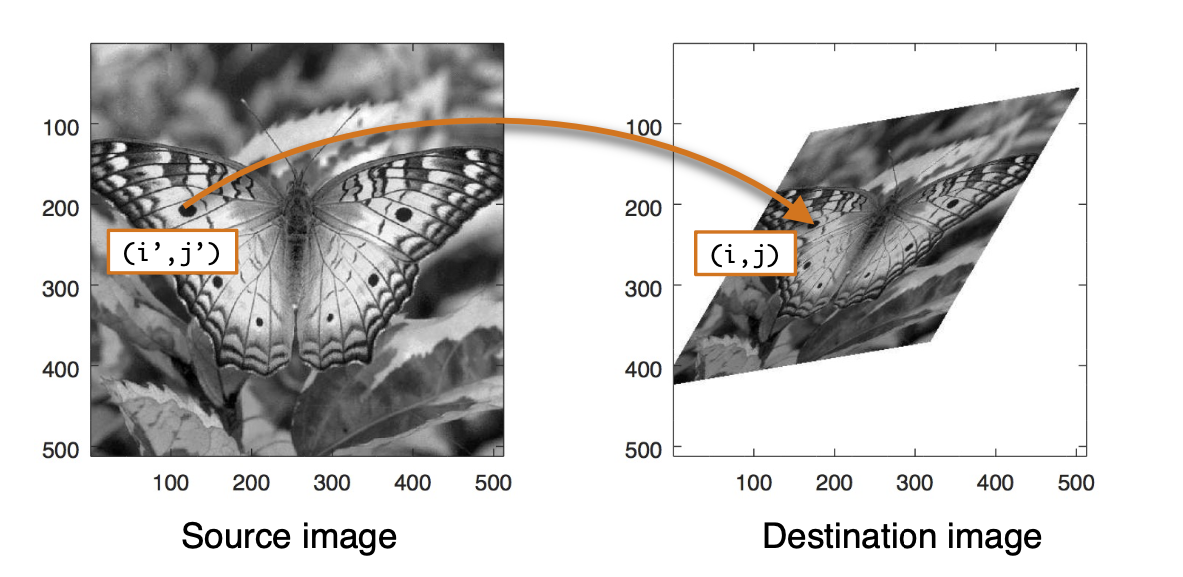

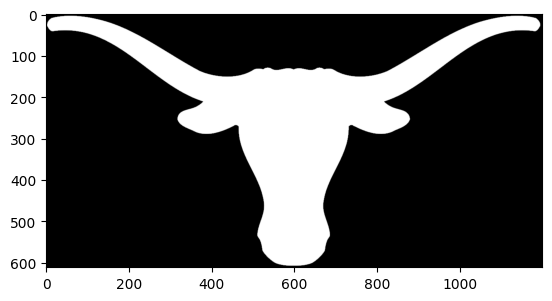

In [ ]:
from matplotlib.image import imread
from matplotlib import pyplot as plt

img = imread('longhorn.png')
X = np.mean(img,-1); # Convert RGB to grayscale
plt.imshow(X,cmap = 'gray')

In [ ]:
# define the warp operator and shift operator
A = np.array([[1.8,0.3],[1,1.7]])
b = np.array([[-50,0]])
# warp the image
X_out = np.ones((X.shape[0],X.shape[1]))
for i in range(X.shape[0]):
  for j in range(X.shape[1]):
    temp = np.round(np.dot(A,np.array([i,j]))+b)
    ip = temp[0,0]
    jp = temp[0,1]
    if ip>=0 and ip<X.shape[0] and jp>=0 and jp<X.shape[1]:
      X_out[i,j] = X[int(ip),int(jp)]

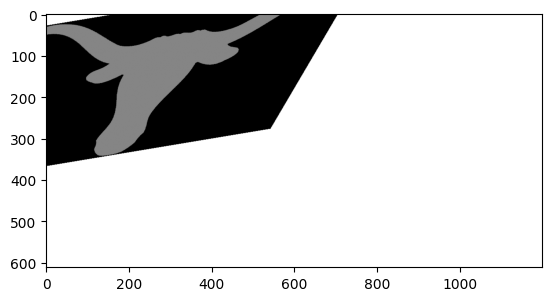

In [ ]:
plt.imshow(X_out,cmap = 'gray')
plt.show()

## 2. Other Operations

### 2.1 Transpose

The transpose of a matrix swaps its rows and columns:


$$\mathbf{A}^T = \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix}^T = \begin{bmatrix} a_{11} & a_{21} \\ a_{12} & a_{22} \end{bmatrix}$$


In [ ]:
m = np.array([[1, 2], [3, 4]])
print("Original Matrix:\n", m)
print("Transpose:\n", m.T)

Original Matrix:
 [[1 2]
 [3 4]]
Transpose:
 [[1 3]
 [2 4]]


### 2.2 Reduction operations
Many reduction functions are available

- np.sum, np.prod
- np.min, np.max
- np.any, np.all

Partial reductions

- np.cumsum, np.cumprod

In [ ]:
X = np.arange(6).reshape(2,3)
X

array([[0, 1, 2],
       [3, 4, 5]])

In [ ]:
print(np.sum(X))

15


In [ ]:
np.sum(X), np.prod(X)

(np.int64(15), np.int64(0))

The way to understand the “axis” of numpy sum is it collapses the specified axis. So when it collapses the axis 0 (row), it becomes just one row and column-wise sum.

In [ ]:
# sum of the rows
np.sum(X, axis=1)

array([ 3, 12])

In [ ]:
# sum of the columns
np.sum(X, axis = 0)

array([3, 5, 7])

In [ ]:
X.sum(axis=1)# equivalent to np.sum(X,axis = 1)

array([ 3, 12])

In [ ]:
np.min(X), np.max(X)

(np.int64(0), np.int64(5))

In [ ]:
X

array([[0, 1, 2],
       [3, 4, 5]])

In [ ]:
np.min(X, axis=0)

array([0, 1, 2])

In [ ]:
X

array([[0, 1, 2],
       [3, 4, 5]])

In [ ]:
Y = X < 4
Y

array([[ True,  True,  True],
       [ True, False, False]])

In [ ]:
# if any rows in Y has an element of True
np.any(Y, axis=1)

array([ True,  True])

In [ ]:
# if any rows in Y has all element of True
np.all(Y, axis=1)

array([ True, False])

All the above functions can be called on the array object directly

In [ ]:
# instance.method(args) = class.method(instance, args)
X.max(axis=0)

array([3, 4, 5])

In [ ]:
# np.cumsum
Y = np.arange(10)
print(Y)
np.cumsum(Y)

[0 1 2 3 4 5 6 7 8 9]


array([ 0,  1,  3,  6, 10, 15, 21, 28, 36, 45])

In [ ]:
X = np.arange(16).reshape(4, 4)
print(X)
np.cumsum(X, axis=1)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]


array([[ 0,  1,  3,  6],
       [ 4,  9, 15, 22],
       [ 8, 17, 27, 38],
       [12, 25, 39, 54]])

Cumulative operations don't change the shape of the array

### 2.3 Shape, reshape and concatenation of matrices

In [ ]:
X = np.arange(50).reshape(10,5)
X

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24],
       [25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34],
       [35, 36, 37, 38, 39],
       [40, 41, 42, 43, 44],
       [45, 46, 47, 48, 49]])

In [ ]:
X.shape

(10, 5)

In [ ]:
X.shape[0]

10

In [ ]:
X.shape[1]

5

In [ ]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
print(A)
print(B)

# Concatenate along rows
result = np.concatenate((A, B), axis=0)
print("Concatenate Along Rows:\n", result)

# Concatenate along columns
result = np.concatenate((A, B), axis=1)
print("Concatenate Along Columns:\n", result)

[[1 2]
 [3 4]]
[[5 6]
 [7 8]]
Concatenate Along Rows:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]
Concatenate Along Columns:
 [[1 2 5 6]
 [3 4 7 8]]


## 3. Linear Algebra in Numpy

In [ ]:
import numpy.linalg as la

### 3.1 Determinant-`la.det`

For a 2x2 matrix:


$$\text{det}(\mathbf{A}) = a_{11}a_{22} - a_{12}a_{21}$$


For $\mathbf{A} = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$:

$$\text{det}(\mathbf{A}) = (1 \cdot 4) - (2 \cdot 3) = -2$$


In [ ]:
matrix = np.array([[1, 2], [3, 4]])
det = la.det(matrix)
print("Determinant:", det)

Determinant: -2.0000000000000004


### 3.2 Inverse-`la.inv`
The inverse of a matrix $\mathbf{A}$ satisfies:

$$\mathbf{A} \cdot \mathbf{A}^{-1} = \mathbf{I}$$


For a 2x2 matrix:

$$\mathbf{A}^{-1} = \frac{1}{\text{det}(\mathbf{A})} \begin{bmatrix} a_{22} & -a_{12} \\ -a_{21} & a_{11} \end{bmatrix}$$


In [ ]:
inverse = la.inv(matrix)
print("Inverse:\n", inverse)

Inverse:
 [[-2.   1. ]
 [ 1.5 -0.5]]


In [ ]:
matrix @ inverse

array([[1.0000000e+00, 0.0000000e+00],
       [8.8817842e-16, 1.0000000e+00]])

### 3.3 Solving Linear System $\mathbf{A}\mathbf{u} = \mathbf {b}$-`la.solve`

Given a system of equations  $\mathbf{A} \mathbf{u} = \mathbf{b}$ :

$$\mathbf{u} = \mathbf{A}^{-1} \cdot \mathbf{b}$$


Example:

$$\mathbf{A} = \begin{bmatrix} 3 & 1 \\ 1 & 2 \end{bmatrix}, \quad \mathbf{b} = \begin{bmatrix} 9 \\ 8 \end{bmatrix}$$

Solution:

$$\mathbf{u} = \begin{bmatrix} 2 \\ 3 \end{bmatrix}$$


In [ ]:
A = np.array([[3, 1], [1, 2]])
b = np.array([9, 8])
u = la.solve(A, b)
print("Solution (u):", u)

Solution (u): [2. 3.]


### Exercise: application of `la.solve`

#### When is an equation or set of equations linear?

Consider theses two linear equations:
$$\begin{aligned}
&y = 5-x\\
&y = 2+3x
\end{aligned}$$

Notice:


*   $x$ and $y$ appear only multiplied by constants
*   $x$ and $y$ are never multiplied by each other
*   any other tems are cosntant




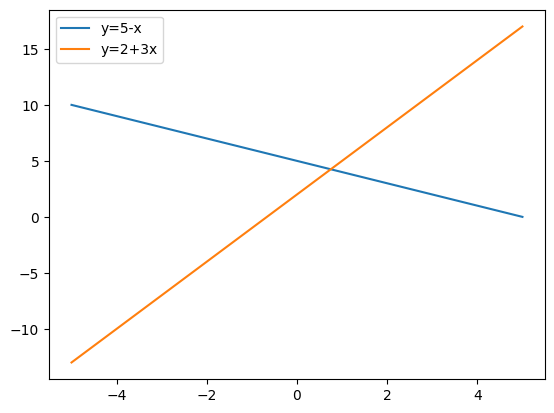

In [ ]:
import matplotlib.pyplot as plt
## we can plot these lines and their intersection
x = np.linspace(-5, 5, 100)
y1 = 5-x
y2 = 2+3*x
plt.plot(x, y1, label='y=5-x')
plt.plot(x, y2, label='y=2+3x')
plt.legend()
plt.show()

The intersection is the same as the simultaneous solution (check yourself): $x = 0.75, y= 4.25$.

#### A common theme will be figuring out how to rewrite equations as a matrix equation:
$$\begin{aligned}
&y = 5-x\\
&y = 2+3x
\end{aligned}\Rightarrow ??? $$
### Strategy:

*  Collect all unknowns on the left hand side
*  Collect all known constants on the right
*  Coefficients in front of the variables go in the matrix
*  Unknowns go into a vector
*  Knowns go into another vector

### After rearranging:
$$\begin{aligned}
&y = 5-x\\
&y = 2+3x
\end{aligned}\Rightarrow \begin{aligned}
&x+y = 5\\
&-3x +y = 2
\end{aligned}$$


### Rewriting as a matrix equation:
$$\begin{aligned}
&y = 5-x\\
&y = 2+3x
\end{aligned}\Rightarrow \begin{aligned}
&x+y = 5\\
&-3x +y = 2
\end{aligned}\Rightarrow \underbrace{\begin{bmatrix}
1&1\\
-3&1\\
\end{bmatrix}}_{\mathbf A}\underbrace{
\begin{bmatrix}
x\\
y
\end{bmatrix}}_{\mathbf u} = \underbrace{\begin{bmatrix}
5\\
2
\end{bmatrix}}_{\mathbf b}$$

In [ ]:
# find u that A@u = b
A = np.array([[1, 1], [-3, 1]])
b = np.array([5, 2])
print("A = \n", A)
print("b = \n", b)

A = 
 [[ 1  1]
 [-3  1]]
b = 
 [5 2]


In [ ]:
u = la.solve(A, b)
print("u = \n", u) # the intersection point

u = 
 [0.75 4.25]


In [ ]:
A @ u

array([5., 2.])

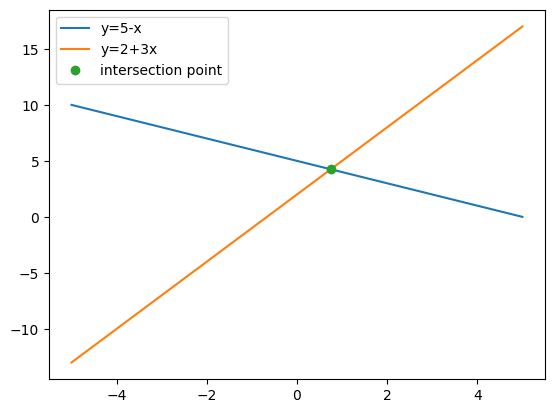

In [ ]:
x = np.linspace(-5, 5, 100)
y1 = 5-x
y2 = 2+3*x
plt.plot(x, y1, label='y=5-x')
plt.plot(x, y2, label='y=2+3x')
plt.plot(u[0],u[1],'o', label = 'intersection point')
plt.legend()
plt.show()

### 3.4 Norm-`la.norm`

The $L_2$ norm of a vector measures its length:

$$\|\mathbf{v}\|_2 = \sqrt{\sum_{i=1}^n v_i^2}$$


For $\mathbf{v} = \begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix}$:

$$\|\mathbf{v}\|_2 = \sqrt{1^2 + 2^2 + 3^2} = \sqrt{14} \approx 3.74$$


In [ ]:
vector = np.array([1,2,3])
norm = la.norm(vector)# default is L2
print("Vector Norm:", norm)

Vector Norm: 3.7416573867739413



Other norms:
* The $L_p$ norm of a vector:

$$\|\mathbf{v}\|_p = \left(\sum_{i=1}^n |v_i|^p\right)^{1/p}$$

* infinity norm:
$$\|\mathbf{v}\|_\infty = \max_i |v_i|$$

In [ ]:
vector = np.array([1,2,3])
norm1 = la.norm(vector,ord = 1)
print("L1 Norm:", norm1)

L1 Norm: 6.0


In [ ]:
vector = np.array([1,2,3])
norm_inf = la.norm(vector, ord = np.inf)
print("L inf Norm:", norm_inf)

L inf Norm: 3.0


* The $L_2$ norm of a matrix (default is $L_2$): largest singular value
* Frobenius norm of a matrix: sum of squared entries $\|A\|_F = \sqrt{\sum_{i,j}a_{i,j}^2}$

In [ ]:
matrix = np.array([[1, 2], [3, 4]])
print(matrix)
matrix_norm = la.norm(matrix)# default is L2
print("Matrix Norm:", matrix_norm)

[[1 2]
 [3 4]]
Matrix Norm: 5.477225575051661


In [ ]:
matrix_norm = la.norm(matrix,ord = 'fro')
print("Frobenius Norm:", matrix_norm)

Frobenius Norm: 5.477225575051661


In [ ]:
help(norm)

Help on float64 object:

class float64(floating, builtins.float)
 |  float64(x=0, /)
 |
 |  Double-precision floating-point number type, compatible with Python
 |  :class:`float` and C ``double``.
 |
 |  :Character code: ``'d'``
 |  :Canonical name: `numpy.double`
 |  :Alias on this platform (Linux x86_64): `numpy.float64`: 64-bit precision floating-point number type: sign bit, 11 bits exponent, 52 bits mantissa.
 |
 |  Method resolution order:
 |      float64
 |      floating
 |      inexact
 |      number
 |      generic
 |      builtins.float
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __abs__(self, /)
 |      abs(self)
 |
 |  __add__(self, value, /)
 |      Return self+value.
 |
 |  __bool__(self, /)
 |      True if self else False
 |
 |  __buffer__(self, flags, /)
 |      Return a buffer object that exposes the underlying memory of the object.
 |
 |  __divmod__(self, value, /)
 |      Return divmod(self, value).
 |
 |  __eq__(self, value, /)
 |      Return self==va

### 3.5 Eigenvalues and Eigenvectors-`la.eig`

For a square matrix $\mathbf{A}$:

$$\mathbf{A} \mathbf{v} = \lambda \mathbf{v}$$

Where:

*	$\lambda$: Eigenvalue.
* $\mathbf{v}$: Eigenvector.




In [ ]:
print(matrix)
eigenvalues, eigenvectors = la.eig(matrix)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

[[1 2]
 [3 4]]
Eigenvalues: [-0.37228132  5.37228132]
Eigenvectors:
 [[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]


 See [the documentation](https://docs.scipy.org/doc/numpy-1.15.1/reference/routines.linalg.html) for more.

* `la.qr`, Computes the QR decomposition
* `la.cholesky`, Computes the Cholesky decomposition
* `la.lstsq(A,b)`, Solves $\arg\min_{\mathbf u} \|\mathbf A\mathbf u-\mathbf b\|_2$
* `la.eigh(A)`, Eigenvalue decomposition for
symmetric or hermitian
* `la.eigvals(A)`, Computes eigenvalues.
* `la.svd(A, full)`, Singular value decomposition
* `la.pinv(A)`, Computes pseudo-inverse of $\mathbf A$